<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
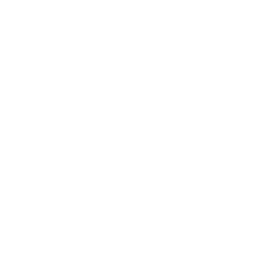
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Valmistuksen vikamuotojen klusterointi</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Valmistus / Laatutekniikka &nbsp;|&nbsp; maaliskuu 2026</p>
</div>
</div>
</div>

## Tiivistelmä

Tämä esimerkki löytää toistuvia **laitteiden vikamuotoja** kussakin vikatapahtumassa tallennetusta moniulotteisesta anturioireprofiilista. Kahdeksan standardoitua oiremuuttujaa (tärinä, lämpötilaero, paineen lasku, virtapiikki, melu, syklinajan poikkeama, vääntömomentin varianssi, öljyhiukkasten määrä) klusteroidaan **täydellisen linkityksen hierarkkisella klusteroinnilla** (`PROC CLUSTER METHOD=COMPLETE`), joka suosii tiiviitä, hyvin erottuvia ryhmiä. `PROC TREE` leikkaa sitten hierarkian **kuudeksi vikamuodoksi**, ja `PROC FREQ` ristiintaulukoi nuo muodot laitetyyppiä ja vuoroa vasten testatakseen systemaattisia yhteyksiä.

Tämä ajo suoritetaan **100 tapahtuman otoksella** (ympäristö rajaa tulosteen 100 havaintoon). Tässä otoksessa kuusi muotoa ovat kooltaan suunnilleen yhtä suuria (n = 16-17 kukin) ja erottuvat ensisijaisesti **lämpötila-, paine- ja tärinä**-tunnusmerkkien perusteella eikä laitetyypin mukaan — muoto-laitetyyppi- ja muoto-vuoro-ristiintaulukoinnit **eivät** ole tilastollisesti merkitseviä tällä otoskoolla (khiin neliö p = 0,15 ja p = 0,07 vastaavasti). Työnkulku skaalautuu muuttumattomana koko tapahtumahistoriaan, jossa suuremmat muotokohtaiset lukumäärät terävöittäisivät näitä yhteyksiä.

## Tietolähteet

| Lähde | Kuvaus | Tietueet |
|--------|-------------|---------|
| WORK.FAILURES | Laitteiden vikatapahtumien oireprofiilit (synteettinen) | 100 |
| WORK.FAILURES_STD | Oireet standardoituna keskiarvoon 0, keskihajontaan 1 (`PROC STANDARD`) | 100 |
| WORK.FAILURE_TREE | Täydellisen linkityksen yhdistämishistoria (`OUTTREE=`) | 100 |
| WORK.FAILURE_MODE_ASSIGNMENTS | Kuuden muodon leikkaus, `PROC TREE NCLUSTERS=6` | 100 |

*Tämä ympäristö toimii lisensoimattomassa tilassa ja rajaa tulosteen 100 havaintoon; synteettinen generaattori pyytää 20 000 tapahtumaa, mutta vain ensimmäiset 100 säilytetään. Alla oleva analyysi perustuu kokonaan tuohon 100 tapahtuman otokseen.*

---

In [1]:
/* --------------------------------------------------------
   Generoi synteettiset vikatapahtumien oireprofiilit
   20 000 vikatapahtumaa 50 laiteyksikön yli
   -------------------------------------------------------- */
TIEDOT work.failures;
    CALL streaminit(42);
    TAULUKKO equip_type_list[4] $16 _temporary_ ('PURISTIN' 'KULJETIN' 'ROBOTTIVARSI' 'UUNI');
    TAULUKKO shift_list[3] $10 _temporary_ ('PAIVA' 'ILTA' 'YO');
    TEE event_id = 1 ASTI 20000;
        failure_id = cat('FE-', KIRJOITA(event_id, z6.));
        equip_num = int(rand('uniform') * 50) + 1;
        equipment_id = cat('EQ-', KIRJOITA(equip_num, z3.));
        etype_idx = int(rand('uniform') * 4) + 1;
        equipment_type = equip_type_list[etype_idx];
        shift_idx = int(rand('uniform') * 3) + 1;
        shift = shift_list[shift_idx];
        failure_date = '01JAN2025'd + int(rand('uniform') * 365);
        /* Oireprofiili: 8 anturilukemaa vikahetkellä */
        vibration_level = round(rand('normal', 4.5, 2.1), 0.01);
        JOS vibration_level < 0 NIIN vibration_level = 0;
        temperature_delta = round(rand('normal', 12, 8), 0.1);
        pressure_drop = round(rand('exponential') * 5, 0.01);
        current_spike = round(rand('normal', 1.2, 0.8), 0.01);
        JOS current_spike < 0 NIIN current_spike = 0;
        noise_db = round(rand('normal', 78, 12), 1);
        cycle_time_deviation = round(rand('normal', 0, 3.5), 0.01);
        torque_variance = round(rand('exponential') * 2.5, 0.01);
        oil_particle_count = int(rand('exponential') * 150 + 10);
        downtime_minutes = round(rand('exponential') * 45 + 5, 1);
        TULOSTE;
    LOPPU;
    POISTA equip_num etype_idx shift_idx;
    MUOTO failure_date date9.;
SUORITA;


NOTE: DATA work.failures

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.failures (100 rows, 15 columns).
NOTE: DATA elapsed:
  wall  6.46 seconds
  cpu   6.46 seconds


---

In [2]:
/* --------------------------------------------------------
   Oireiden perusjakaumat laitetyypeittäin
   -------------------------------------------------------- */
PROSEDUURI KESKIARVOT TIEDOT=work.failures n mean std MAX;
    LUOKKA equipment_type;
    MUUTTUJA vibration_level temperature_delta pressure_drop
        current_spike noise_db torque_variance oil_particle_count;
    NIMIKE equipment_type   = 'Laitetyyppi'
           vibration_level  = 'Värähtelytaso'
           temperature_delta= 'Lämpötilaero (C)'
           pressure_drop    = 'Paineen lasku'
           current_spike    = 'Virtapiikki'
           noise_db         = 'Melu (dB)'
           torque_variance  = 'Vääntömomentin varianssi'
           oil_particle_count = 'Öljyhiukkasten määrä';
    OTSIKKO 'Vikaoireiden profiilit laitetyypeittäin';
SUORITA;

                                        Vikaoireiden profiilit laitetyypeittäin                                         

                                                  The MEANS Procedure

                                  Analysis Variable : vibration_level Värähtelytaso

        Laitetyyppi           N Obs           Mean        Std Dev        Maximum
        ------------------------------------------------------------------------
        KULJETIN                 19      3.8089474      1.8662437      9.0400000
        PURISTIN                 30      4.6273333      2.1610740      9.9400000
        ROBOTTIVARSI             25      3.5320000      1.9296070      6.7900000
        UUNI                     26      4.3638462      2.0371177     10.1400000
        ------------------------------------------------------------------------

                                Analysis Variable : temperature_delta Lämpötilaero (C)

        Laitetyyppi           N Obs           Mean        Std Dev 


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                        Vikaoireiden profiilit laitetyypeittäin                                         




NOTE: PROC SGPLOT data=work.failures

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


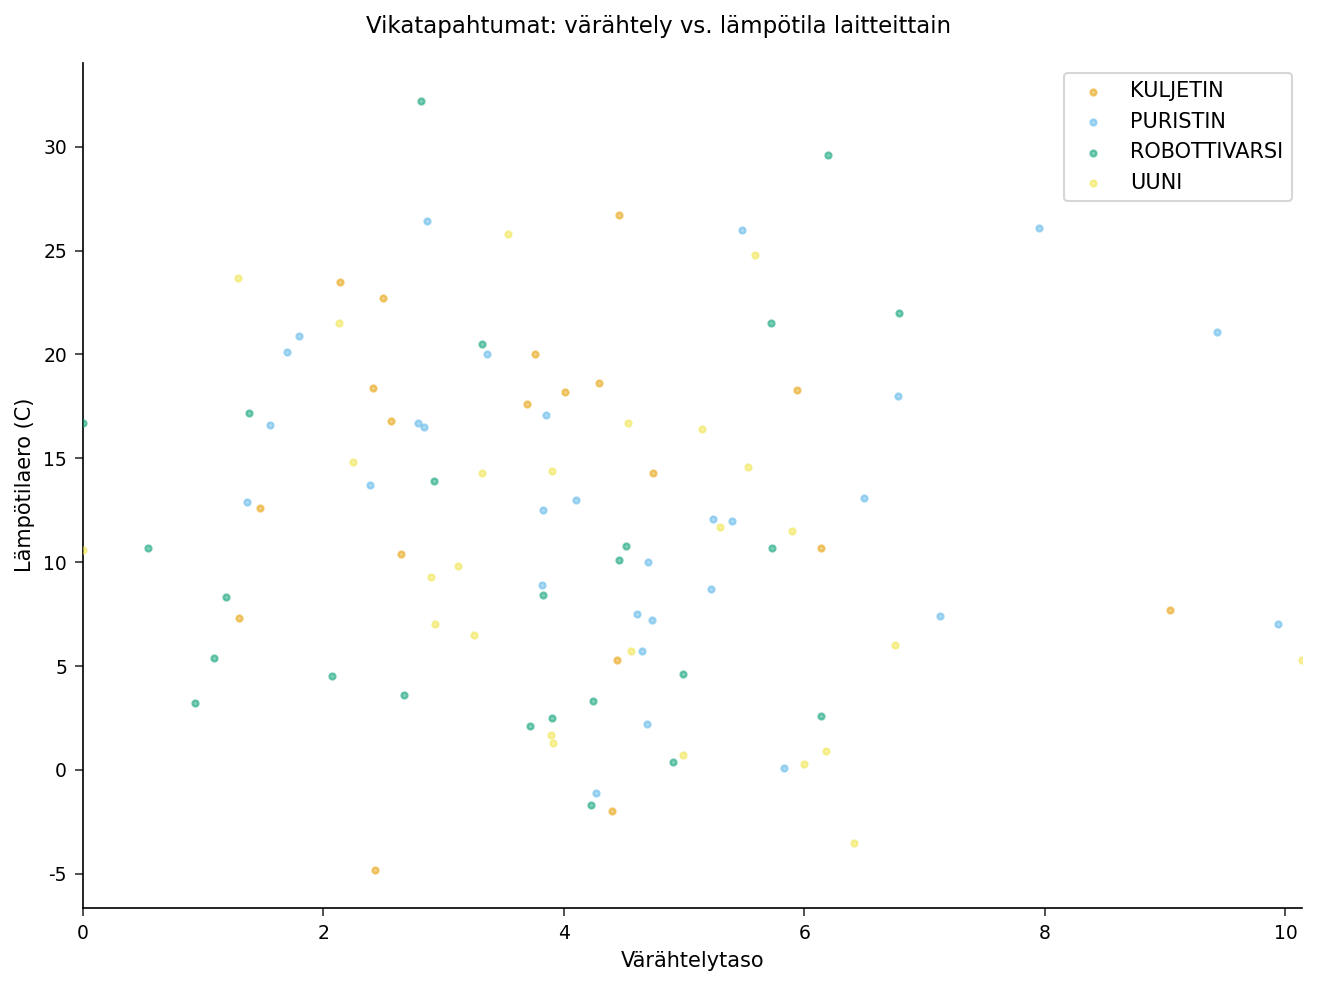

In [3]:
/* --------------------------------------------------------
   Varahtely vs. lämpötilaero laitetyypeittäin
   -------------------------------------------------------- */
PROSEDUURI SGPLOT TIEDOT=work.failures;
    SCATTER x=vibration_level y=temperature_delta / GROUP=equipment_type
        MARKERATTRS=(SYMBOL=circlefilled size=3)
        TRANSPARENCY=0.5;
    XAXIS NIMIKE='Värähtelytaso';
    YAXIS NIMIKE='Lämpötilaero (C)';
    OTSIKKO 'Vikatapahtumat: värähtely vs. lämpötila laitteittain';
SUORITA;

---

In [4]:
/* --------------------------------------------------------
   Standardoi oiremuuttujat klusterointia varten
   -------------------------------------------------------- */
PROSEDUURI STANDARD TIEDOT=work.failures out=work.failures_std
    mean=0 std=1;
    MUUTTUJA vibration_level temperature_delta pressure_drop
        current_spike noise_db cycle_time_deviation
        torque_variance oil_particle_count;
SUORITA;


NOTE: PROC STANDARD data=work.failures

NOTE: Standardized 100 rows, 8 variables.


                                        Vikaoireiden profiilit laitetyypeittäin                                         

                                                 The CLUSTER Procedure
                                           Complete Linkage Cluster Analysis

                                          Eigenvalues of the Covariance Matrix

                                                    Cluster History

   NCL    --------Clusters Joined--------    FREQ    SPRSQ      RSQ    Distance

    99    FE-00005          FE-00006        2    0.0007    0.9993          1
    98    FE-00007          FE-00008        2    0.0007    0.9986          1
    97    FE-00000          FE-00004        2    0.0009    0.9977        1.2
    96    FE-00002          FE-00008        2    0.0009    0.9968        1.2
    95    FE-00000          FE-00001        2    0.0010    0.9958        1.3
    94    FE-00005          FE-00008        2    0.0011    0.9947        1.3
    93    FE-00004          CL99     


NOTE: PROC CLUSTER data=work.failures_std method=Complete

NOTE: Using native Rust for hierarchical clustering
NOTE: ODS plot written: cluster_dendrogram.spec.json
NOTE: PROC CLUSTER ODS Graphics generated.
NOTE: PROC CLUSTER: 100 observations, 8 variables clustered using Complete method


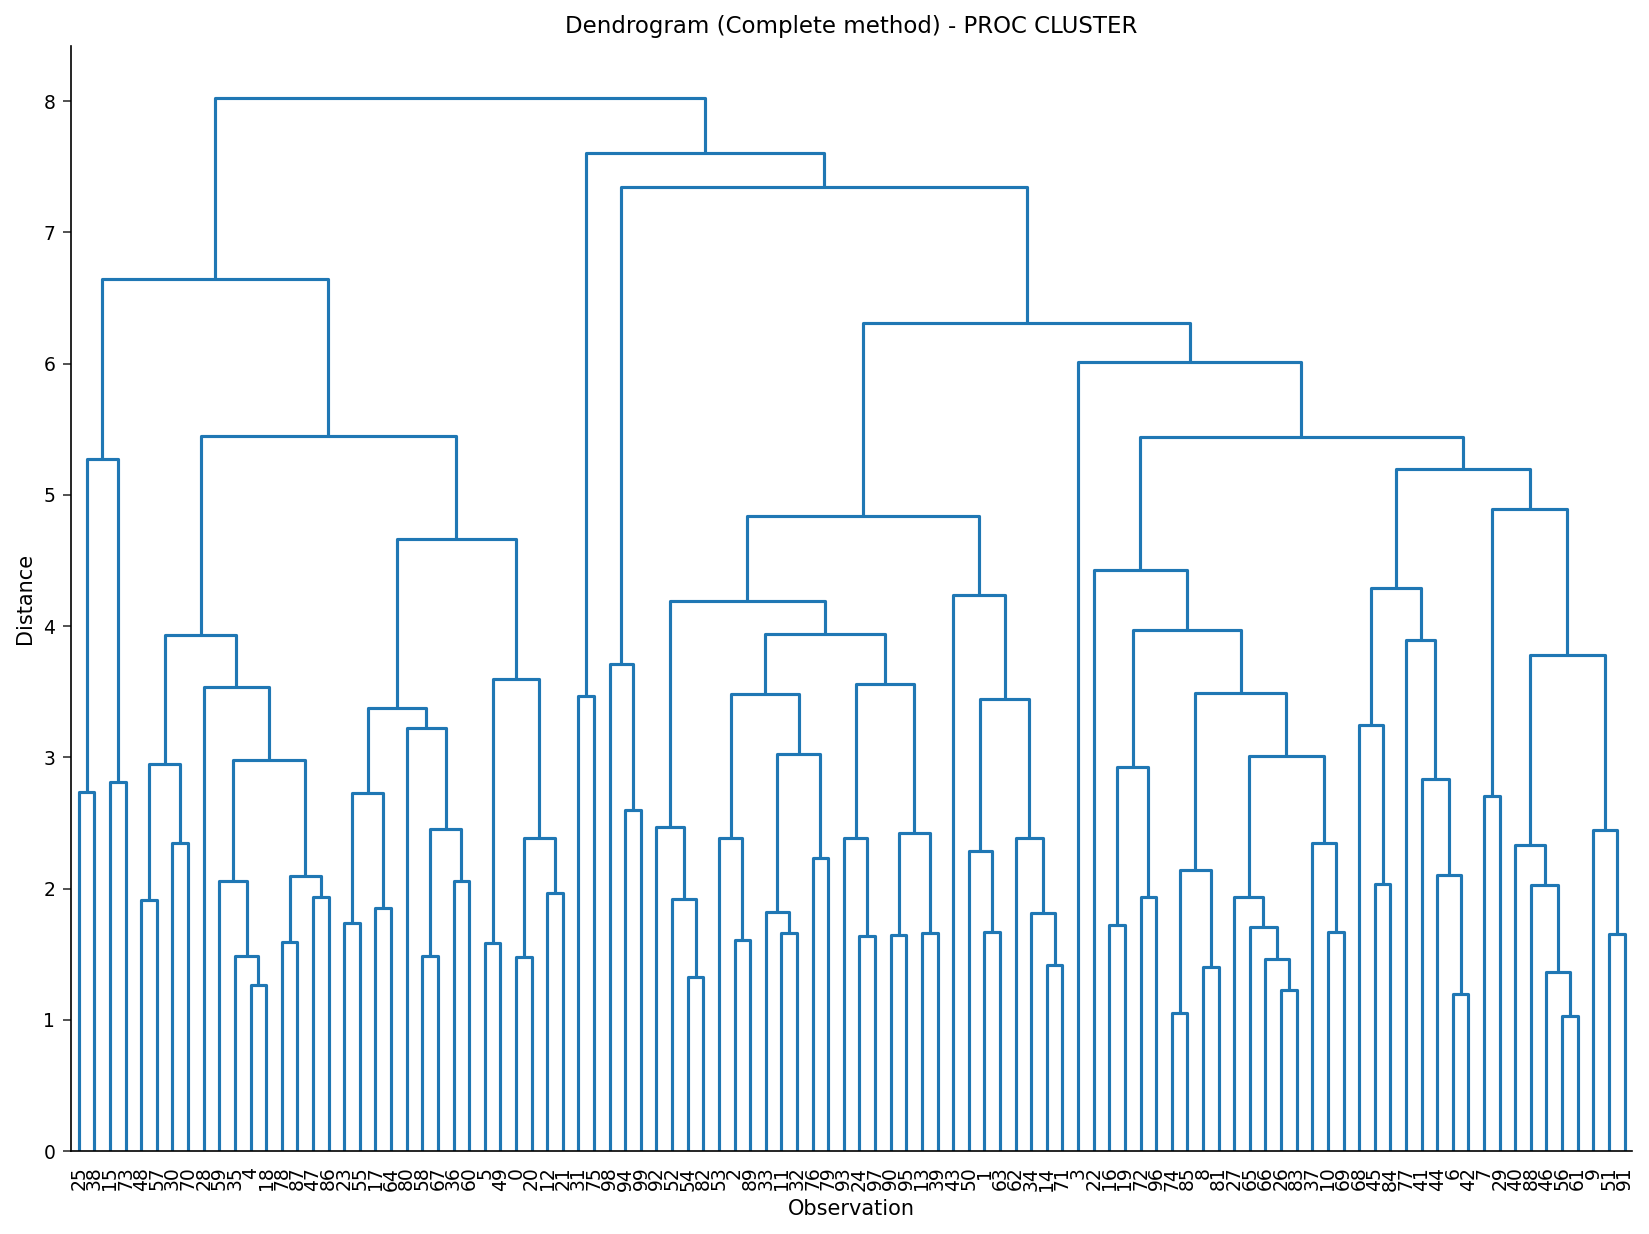

In [5]:
/* --------------------------------------------------------
   Täydellisen linkityksen klusterointi TRIM=-optiolla
   poikkeamien poistoon. TRIM=5 poistaa 5 % kaukaisimmista
   havainnoista ennen klustereiden muodostamista.
   -------------------------------------------------------- */
PROSEDUURI CLUSTER TIEDOT=work.failures_std METHOD=complete
    outtree=work.failure_tree
    pseudo TULOSTA=20 trim=5;
    MUUTTUJA vibration_level temperature_delta pressure_drop
        current_spike noise_db cycle_time_deviation
        torque_variance oil_particle_count;
    id failure_id;
SUORITA;

In [6]:
/* --------------------------------------------------------
   Leikkaa täydellisen linkityksen hierarkia kuudeksi
   vikamuodoksi PROC TREE -proseduurilla (NCLUSTERS=6).
   Kuusi on valittu käytännölliseksi, tulkittavaksi
   tarkkuudeksi triagea varten; alla näytetään
   yhdistämisrakenne, jonka tämä leikkaus jakaa.
   -------------------------------------------------------- */
PROSEDUURI TREE TIEDOT=work.failure_tree
    out=work.failure_mode_assignments
    nclusters=6;
    id failure_id;
SUORITA;

                                        Vikaoireiden profiilit laitetyypeittäin                                         




NOTE: PROC TREE data=work.failure_tree

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: PROC TREE dendrogram SVG generated.
NOTE: PROC TREE: Extracted 6 clusters using Python/scipy


In [7]:
/* --------------------------------------------------------
   Yhdistä luokitukset ja profiloi vikamuodot
   -------------------------------------------------------- */
TIEDOT work.failures_classified;
    YHDISTÄ work.failures
          work.failure_mode_assignments(NIMEÄ_UUDELLEEN=(CLUSTER=failure_mode));
    MUKAAN failure_id;
SUORITA;

PROSEDUURI KESKIARVOT TIEDOT=work.failures_classified n mean std;
    LUOKKA failure_mode;
    MUUTTUJA vibration_level temperature_delta pressure_drop
        current_spike noise_db torque_variance
        oil_particle_count downtime_minutes;
    NIMIKE failure_mode     = 'Vikamuoto'
           vibration_level  = 'Värähtelytaso'
           temperature_delta= 'Lämpötilaero (C)'
           pressure_drop    = 'Paineen lasku'
           current_spike    = 'Virtapiikki'
           noise_db         = 'Melu (dB)'
           torque_variance  = 'Vääntömomentin varianssi'
           oil_particle_count = 'Öljyhiukkasten määrä'
           downtime_minutes = 'Seisokki (min)';
    OTSIKKO 'Vikamuotojen oireprofiilit (k=6)';
SUORITA;

                                            Vikamuotojen oireprofiilit (k=6)                                            

                                                  The MEANS Procedure

                                  Analysis Variable : vibration_level Värähtelytaso

        Vikamuoto          N Obs           Mean        Std Dev
        ------------------------------------------------------
        1                     17      4.3470588      2.6168582
        2                     17      4.2552941      2.2610427
        3                     17      3.6870588      1.8669720
        4                     17      4.0500000      2.0351843
        5                     16      3.4793750      1.4636870
        6                     16      4.9693750      1.6907177
        ------------------------------------------------------

                                Analysis Variable : temperature_delta Lämpötilaero (C)

        Vikamuoto          N Obs           Mean        Std Dev
   


NOTE: DATA work.failures_classified

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.failures_classified (100 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


                                     Vikamuotojen jakauma laitteen ja vuoron mukaan                                     

                                                   The FREQ Procedure

Table of Vikamuoto by Laitetyyppi

Vikamuoto |    KULJETIN |    PURISTIN |ROBOTTIVARSI |        UUNI |        Total
----------+-------------+-------------+-------------+-------------+-------------
1         |           4 |           7 |           1 |           5 |           17
----------+-------------+-------------+-------------+-------------+-------------
2         |           3 |           2 |           7 |           5 |           17
----------+-------------+-------------+-------------+-------------+-------------
3         |           6 |           2 |           4 |           5 |           17
----------+-------------+-------------+-------------+-------------+-------------
4         |           1 |           7 |           4 |           5 |           17
----------+-------------+-------------+----


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_failure_mode_equipment_type.spec.json
NOTE: ODS plot written: freq_mosaic_failure_mode_shift.spec.json
NOTE: PROC FREQ statement used.


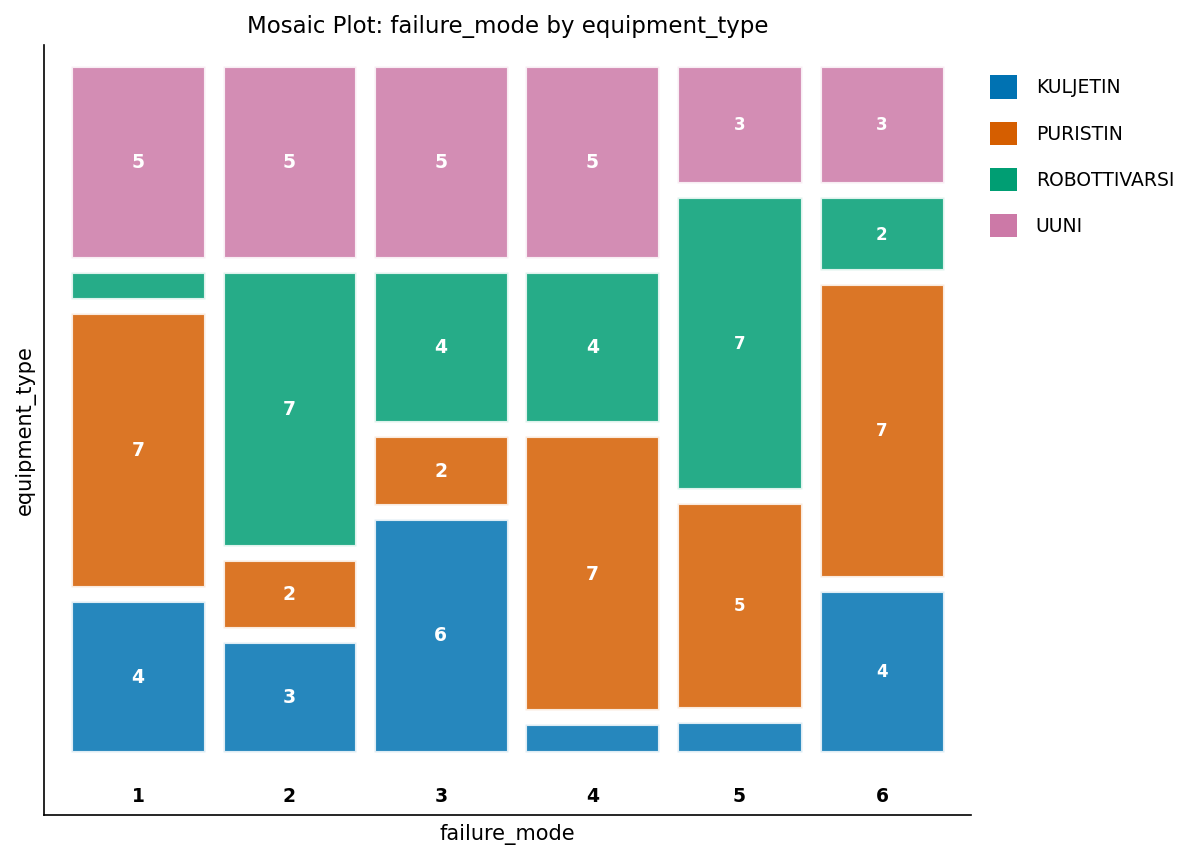

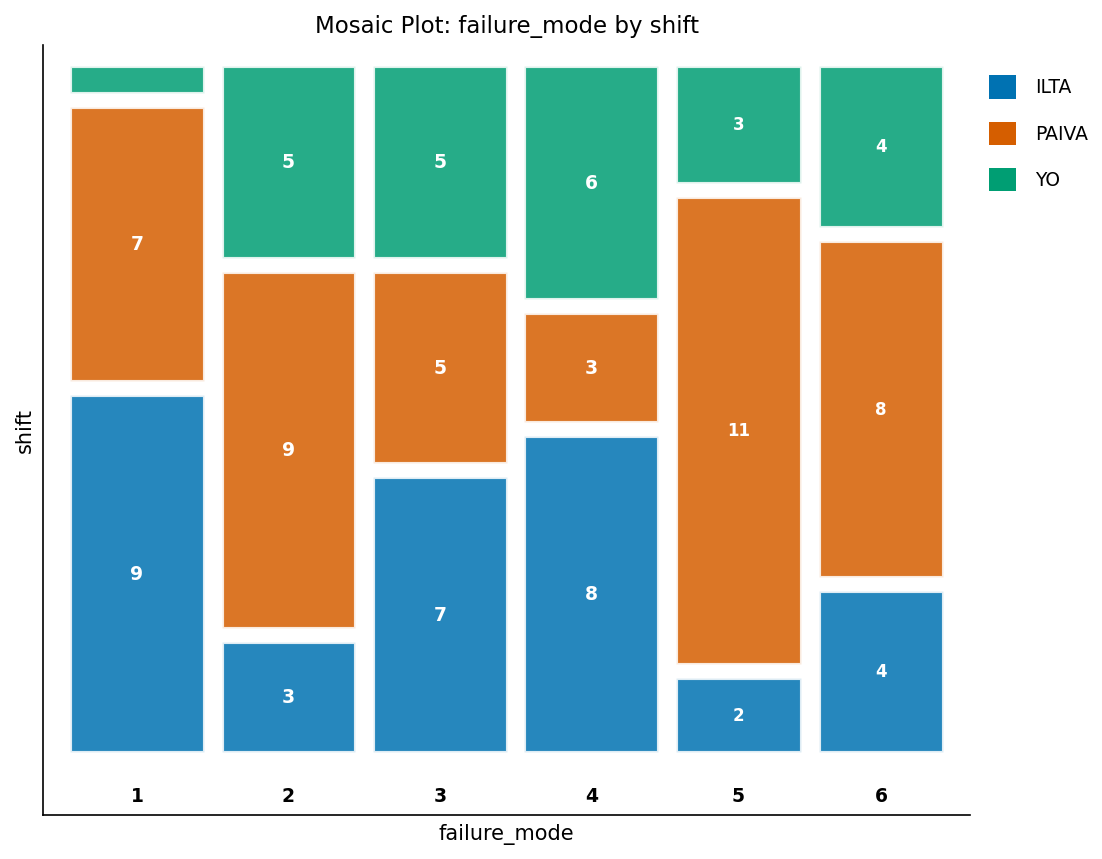

In [8]:
/* --------------------------------------------------------
   Ristiintaulukoi vikamuodot laitetyyppiä ja vuoroa
   vasten systemaattisten kaavojen tunnistamiseksi
   -------------------------------------------------------- */
PROSEDUURI FREKVENSSIT TIEDOT=work.failures_classified;
    TABLES failure_mode * equipment_type / chisq nocol nopercent;
    TABLES failure_mode * shift / chisq nocol nopercent;
    NIMIKE failure_mode   = 'Vikamuoto'
           equipment_type = 'Laitetyyppi'
           shift          = 'Vuoro';
    OTSIKKO 'Vikamuotojen jakauma laitteen ja vuoron mukaan';
SUORITA;

---

### Tulkinta

100 standardoidun vikatapahtuman täydellisen linkityksen klusterointi tuottaa **kuusi vikamuotoa**, jotka ovat lähes yhtä suuria (n = 17, 17, 17, 17, 16, 16). Muodot erotetaan niiden oiretunnusmerkkien perusteella yllä olevassa `PROC MEANS` -profiilissa:

- **Muoto 6** kantaa raskaimman mekaanisen rasituksen tunnusmerkin: korkein keskimääräinen tärinä (4,97), korkein paineen lasku (7,51) ja korkein virtapiikki (1,61) — mutta **matalin** vääntömomentin varianssi (1,28).
- **Muoto 3** on terminen muoto: korkein lämpötilaero (16,3 C) ja matalin keskimääräinen melu (73,0 dB).
- **Muodolla 2** on **pisin seisokkiaika** selvällä marginaalilla (keskiarvo 85,6 minuuttia vs. 31-52 muille muodoille) ja kohonnut vääntömomentin varianssi (3,57), mikä viittaa tapahtumiin, joista toipuminen on kalliimpaa.
- **Muoto 4** on lievin: matalin seisokkiaika (31,4 minuuttia) sekä keskimääräistä matalampi paineen lasku ja öljyhiukkasten määrä.
- **Muodot 1 ja 5** ovat sekaoireisia ryhmiä ilman yhtä hallitsevaa tekijää.

`PROC FREQ` -ristiintaulukoinnit testaavat, keskittyvätkö nämä muodot tiettyihin laitteisiin tai vuoroihin. Tällä otoskoolla ne **eivät** keskity: muoto-laitetyyppi antaa khiin neliön = 20,48 (15 vapausastetta, p = 0,154, Cramérin V = 0,26) ja muoto-vuoro antaa khiin neliön = 17,13 (10 vapausastetta, p = 0,072, Cramérin V = 0,29) — molemmat yli 0,05-kynnyksen, ja yli 80 %:lla soluista odotetut lukumäärät ovat alle 5, joten khiin neliö on itsessään vain suuntaa-antava. Näkyvät kallistumat (muoto 6 nojaten PURISTIN-suuntaan, muoto 5 päivävuoroon) ovat tässä kuvailevia eivätkä merkitseviä.

**Johtopäätös:** täydellinen linkitys standardoiduilla oireprofiileilla tuottaa tulkittavan kuuden muodon taksonomian, joka on avaimennettu lämpötilaan, paineeseen ja seisokkiaikaan. Vahvistaakseen, kartoittuvatko muodot tiettyihin laitteisiin tai vuoroihin — toimintakelpoinen juurisyykysymys — analyysi tarvitsee koko tapahtumahistorian tämän 100 tapahtuman otoksen sijaan, jossa ristiintaulukoinnit pysyvät alivoimaisina.

---

In [9]:
/* --------------------------------------------------------
   Vie vikaluokitukset CMMS-integraatiota varten
   -------------------------------------------------------- */
PROSEDUURI VIE TIEDOT=work.failures_classified
    OUTFILE='failure_mode_classifications.csv'
    DBMS=csv REPLACE;
SUORITA;


NOTE: PROC EXPORT data=work.failures_classified outfile=failure_mode_classifications.csv

NOTE: Exported 100 rows to failure_mode_classifications.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Luottamuksellinen
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Käyttövoimana <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>